<a href="https://colab.research.google.com/github/Mario-Cattaneo/SemesterProject/blob/main/Eval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Imports and Device Setup
import copy
import math
from dataclasses import dataclass, field
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing on device: {device}")

Executing on device: cuda


In [ ]:
# Cell 2: Hierarchical Configuration with Unified Time Units (ms & bits)
from dataclasses import dataclass, field
import math
from typing import Dict, List, Tuple
import numpy as np
import torch
import torch.nn as nn


@dataclass
class ChannelConfig:
    capacity_bits_per_ms: (
        float  # Capacity in bits/ms (e.g., 30 Mbps = 30,000 bits/ms)
    )
    prop_delay_ms: float  # Propagation delay in ms
    bit_width: int = 8  # b bits per scalar component

    @classmethod
    def from_mbps(cls, capacity_mbps: float, prop_delay_ms: float, bit_width=8):
        """Helper: converts Mbps to bits/ms (1 Mbps = 1,000 bits/ms)."""
        return cls(
            capacity_bits_per_ms=capacity_mbps * 1000.0,
            prop_delay_ms=prop_delay_ms,
            bit_width=bit_width,
        )


@dataclass
class NodeConfig:
    device_name: str
    exec_time_ms: float  # Device execution delay t_i^exec in ms


@dataclass
class ToleranceConfig:
    epsilon_ms: float = 0.8  # Global tolerance band [t_target - eps, t_target]
    epsilon_margin_ms: float = (
        0.3  # Max allowed SLA ceiling margin (t_target + margin)
    )


@dataclass
class ALMConfig:
    t_max: float  # Target SLA in ms
    lambda1_init: float = 0.0
    lambda2_init: float = 0.005
    rho: float = 1.5
    tau_viol: float = 0.25
    e_step: int = 2


@dataclass
class GateConfig:
    alpha: float = 10.0  # Smooth-max sharpness (constant)
    beta_init: float = 1.5
    beta_min: float = 0.05
    decay_rate: float = 0.90
    gamma: float = -0.1
    zeta: float = 1.1
    s_init: float = 1.0


@dataclass
class ExperimentConfig:
    experiment_name: str = "TBN_Component_Level"
    batch_size: int = 128
    epochs: int = 8
    lr_s: float = 0.05  # Learning rate for component gates
    lr_c: float = 0.01  # Learning rate for continuous imputations
    nodes: Dict[int, NodeConfig] = field(default_factory=dict)
    edges: Dict[Tuple[int, int], ChannelConfig] = field(default_factory=dict)
    alm: ALMConfig = field(default_factory=lambda: ALMConfig(t_max=25.0))
    gate: GateConfig = field(default_factory=GateConfig)
    tolerance: ToleranceConfig = field(default_factory=ToleranceConfig)


print("Cell 2: Unified configuration layer ready.")

Cell 2: Unified configuration layer ready.


In [ ]:
# Cell 3: True Component-Level (Element-Wise) Gating and Imputation


class EdgeBottleneck(nn.Module):
    """Component-level gating: learns one gate s and one imputation c for every

    individual scalar feature k in D_{i,j}.
    """

    def __init__(
        self,
        feature_shape: Tuple[int, ...],
        channel_cfg: ChannelConfig,
        gate_cfg: GateConfig,
    ):
        super().__init__()
        self.feature_shape = feature_shape  # e.g., (32, 32, 32)
        self.channel_cfg = channel_cfg
        self.gate_cfg = gate_cfg

        self.total_components = int(np.prod(feature_shape))

        # s and c match the EXACT tensor dimensions (C, H, W)
        self.s = nn.Parameter(torch.full(feature_shape, gate_cfg.s_init))
        self.c = nn.Parameter(torch.zeros(feature_shape))

    def get_transmission_prob(self, beta: float) -> torch.Tensor:
        """p(m_i,j^(k) > 0) evaluated component-wise."""
        offset = beta * math.log(-self.gate_cfg.gamma / self.gate_cfg.zeta)
        return torch.sigmoid(self.s - offset)

    def expected_transmission_time_ms(self, beta: float) -> torch.Tensor:
        """t_trans = (b * E[|Omega|]) / C [bits / (bits/ms) = ms]."""
        probs = self.get_transmission_prob(beta)
        expected_active_components = torch.sum(probs)
        total_bits = expected_active_components * self.channel_cfg.bit_width
        # Direct unified division: bits / (bits/ms) = ms
        trans_time_ms = total_bits / self.channel_cfg.capacity_bits_per_ms
        return trans_time_ms

    def forward(
        self, z: torch.Tensor, beta: float, deterministic: bool = False
    ) -> Tuple[torch.Tensor, float]:
        s_broad = self.s.unsqueeze(0)
        c_broad = self.c.unsqueeze(0)

        if not deterministic:
            eps = torch.rand_like(s_broad).clamp(1e-6, 1.0 - 1e-6)
            logits_eps = torch.log(eps) - torch.log(1.0 - eps)
            m_tilde = torch.sigmoid((logits_eps + s_broad) / beta)
            m_bar = (
                m_tilde * (self.gate_cfg.zeta - self.gate_cfg.gamma)
                + self.gate_cfg.gamma
            )
            m = torch.clamp(m_bar, 0.0, 1.0)

            # u^(k) = z^(k) * m^(k) + (1 - m^(k)) * c^(k)
            u = z * m + (1.0 - m) * c_broad
            active_fraction = float(m.mean().item())
            return u, active_fraction
        else:
            threshold = beta * math.log(
                -self.gate_cfg.gamma / self.gate_cfg.zeta
            )
            hard_mask = (s_broad >= threshold).float()

            u = z * hard_mask + (1.0 - hard_mask) * c_broad
            active_fraction = float(hard_mask.mean().item())
            return u, active_fraction


print("Cell 3: Component-level EdgeBottleneck compiled.")

Cell 3: Component-level EdgeBottleneck compiled.


In [ ]:
# Cell 4: DAGTimingEngine with Direct Millisecond Summation


class DAGTimingEngine:

    def __init__(
        self,
        nodes: Dict[int, NodeConfig],
        edges: Dict[Tuple[int, int], ChannelConfig],
    ):
        self.nodes = nodes
        self.edges = edges

        self.parents: Dict[int, List[int]] = {i: [] for i in nodes}
        self.children: Dict[int, List[int]] = {i: [] for i in nodes}
        for u, v in edges.keys():
            self.parents[v].append(u)
            self.children[u].append(v)

        self.topo_order = self._get_topological_sort()
        self.terminal_node = self.topo_order[-1]

    def _get_topological_sort(self) -> List[int]:
        in_deg = {i: len(self.parents[i]) for i in self.nodes}
        queue = [i for i in self.nodes if in_deg[i] == 0]
        order = []
        while queue:
            curr = queue.pop(0)
            order.append(curr)
            for nxt in self.children[curr]:
                in_deg[nxt] -= 1
                if in_deg[nxt] == 0:
                    queue.append(nxt)
        return order

    def compute_relaxed_latency(
        self,
        bottlenecks: Dict[Tuple[int, int], EdgeBottleneck],
        beta: float,
        alpha: float,
    ) -> torch.Tensor:
        t_tilde: Dict[int, torch.Tensor] = {}

        for j in self.topo_order:
            t_exec = torch.tensor(
                self.nodes[j].exec_time_ms, device=bottlenecks[(0, 1)].s.device
            )

            if len(self.parents[j]) == 0:
                t_tilde[j] = t_exec
            else:
                branch_arrivals = []
                for i in self.parents[j]:
                    t_trans = bottlenecks[(i, j)].expected_transmission_time_ms(
                        beta
                    )
                    t_prop = torch.tensor(
                        self.edges[(i, j)].prop_delay_ms, device=t_trans.device
                    )
                    z_ij = (
                        t_tilde[i] + t_prop + t_trans
                    )  # All terms strictly in ms
                    branch_arrivals.append(z_ij)

                stacked = torch.stack(branch_arrivals)
                z_max = torch.max(stacked).detach()
                lse = z_max + (1.0 / alpha) * torch.log(
                    torch.sum(torch.exp(alpha * (stacked - z_max)))
                )
                t_tilde[j] = t_exec + lse

        return t_tilde[self.terminal_node]

    def compute_physical_latency(
        self,
        bottlenecks: Dict[Tuple[int, int], EdgeBottleneck],
        beta: float,
        deterministic: bool = True,
    ) -> float:
        t_physical: Dict[int, float] = {}

        for j in self.topo_order:
            t_exec = self.nodes[j].exec_time_ms

            if len(self.parents[j]) == 0:
                t_physical[j] = t_exec
            else:
                branch_delays = []
                for i in self.parents[j]:
                    bneck = bottlenecks[(i, j)]
                    if deterministic:
                        thresh = beta * math.log(
                            -bneck.gate_cfg.gamma / bneck.gate_cfg.zeta
                        )
                        active_components = (bneck.s >= thresh).sum().item()
                    else:
                        active_components = (
                            bneck.get_transmission_prob(beta).sum().item()
                        )

                    total_bits = (
                        active_components * bneck.channel_cfg.bit_width
                    )
                    # bits / (bits/ms) = ms
                    t_trans = (
                        total_bits / self.edges[(i, j)].capacity_bits_per_ms
                    )
                    t_prop = self.edges[(i, j)].prop_delay_ms
                    branch_delays.append(t_physical[i] + t_prop + t_trans)

                t_physical[j] = t_exec + max(branch_delays)

        return t_physical[self.terminal_node]

    def compute_irreducible_latency(self) -> float:
        """Physical floor when t_trans -> 0 (ms)."""
        t_floor: Dict[int, float] = {}
        for j in self.topo_order:
            t_exec = self.nodes[j].exec_time_ms
            if len(self.parents[j]) == 0:
                t_floor[j] = t_exec
            else:
                branch_delays = [
                    t_floor[i] + self.edges[(i, j)].prop_delay_ms
                    for i in self.parents[j]
                ]
                t_floor[j] = t_exec + max(branch_delays)
        return t_floor[self.terminal_node]


print("Cell 4: DAGTimingEngine ready.")

Cell 4: DAGTimingEngine ready.


In [ ]:
# Cell 5: Collaborative ResNet DAG with Residual Micro-Splits


class ResBlock(nn.Module):

    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(
                channels,
                channels,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Conv2d(
                channels,
                channels,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(channels),
        )

    def forward(self, x):
        return F.relu(x + self.conv(x))


class CollaborativeResNetDAG(nn.Module):

    def __init__(self, cfg: ExperimentConfig):
        super().__init__()
        self.cfg = cfg

        # Device 0: Input Stem + ResBlock (Outputs 64 channels)
        self.node0_split = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            ResBlock(64),
        )

        # Device 1: Parallel Worker A (Processes 32 channels -> outputs 64)
        self.node1_split = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            ResBlock(64),
        )

        # Device 2: Parallel Worker B (Processes 32 channels -> outputs 64)
        self.node2_split = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            ResBlock(64),
        )

        # Device 3: Concatenation (64+64 = 128 channels) + ResBlock + Classifier
        self.node3_split = nn.Sequential(
            ResBlock(128),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, 10),
        )

        # EdgeBottlenecks for directed channels
        self.bottlenecks = nn.ModuleDict()
        self.bottlenecks["0->1"] = EdgeBottleneck(
            (32, 32, 32), cfg.edges[(0, 1)], cfg.gate
        )
        self.bottlenecks["0->2"] = EdgeBottleneck(
            (32, 32, 32), cfg.edges[(0, 2)], cfg.gate
        )
        self.bottlenecks["1->3"] = EdgeBottleneck(
            (64, 16, 16), cfg.edges[(1, 3)], cfg.gate
        )
        self.bottlenecks["2->3"] = EdgeBottleneck(
            (64, 16, 16), cfg.edges[(2, 3)], cfg.gate
        )

    def get_bottleneck_map(self) -> Dict[Tuple[int, int], EdgeBottleneck]:
        return {
            (0, 1): self.bottlenecks["0->1"],
            (0, 2): self.bottlenecks["0->2"],
            (1, 3): self.bottlenecks["1->3"],
            (2, 3): self.bottlenecks["2->3"],
        }

    def forward(
        self, x: torch.Tensor, beta: float, deterministic: bool = False
    ) -> torch.Tensor:
        z0 = self.node0_split(x)
        z0_A, z0_B = torch.split(z0, 32, dim=1)

        u01, _ = self.bottlenecks["0->1"](
            z0_A, beta, deterministic=deterministic
        )
        u02, _ = self.bottlenecks["0->2"](
            z0_B, beta, deterministic=deterministic
        )

        z1 = self.node1_split(u01)
        z2 = self.node2_split(u02)

        u13, _ = self.bottlenecks["1->3"](
            z1, beta, deterministic=deterministic
        )
        u23, _ = self.bottlenecks["2->3"](
            z2, beta, deterministic=deterministic
        )

        z_concat = torch.cat([u13, u23], dim=1)
        return self.node3_split(z_concat)


print("Cell 5: Upgraded residual architecture ready.")

Cell 5: Upgraded residual architecture ready.


In [10]:
# ==============================================================================
# Cell 6: Symmetrical Single-Hyperparameter Trainer with Multi-Fidelity Support
# ==============================================================================
import copy
import torch.optim as optim


class UnifiedTradeoffTrainer:
    """Symmetrical trainer for all 3 unconstrained approaches:

    - 'uniform_bits': L_task + beta * Sum(Raw Bits)
    - 'capacity_delay': L_task + mu * Sum(Raw Transmission Delays in ms)
    - 'critical_path': L_task + gamma * Critical-Path Latency (tilde{t} in ms)
    Supports fast diagnostic probing via max_batches.
    """

    def __init__(
        self,
        model: CollaborativeResNetDAG,
        timing_engine: DAGTimingEngine,
        cfg: ExperimentConfig,
        weight: float,
        mode: str,
    ):
        self.model = model.to(device)
        self.timing_engine = timing_engine
        self.cfg = cfg
        self.weight = weight
        self.mode = mode

        s_params = [
            bneck.s for bneck in self.model.get_bottleneck_map().values()
        ]
        c_params = [
            bneck.c for bneck in self.model.get_bottleneck_map().values()
        ]
        self.optimizer = optim.Adam(
            [
                {"params": s_params, "lr": cfg.lr_s},
                {"params": c_params, "lr": cfg.lr_c},
            ]
        )
        self.criterion = nn.CrossEntropyLoss()

    def train_epoch(
        self, dataloader, epoch: int, max_batches: int = None
    ) -> float:
        self.model.train()
        beta = max(
            self.cfg.gate.beta_min, self.cfg.gate.beta_init * (self.cfg.gate.decay_rate**epoch)
        )
        bneck_map = self.model.get_bottleneck_map()
        running_loss = 0.0

        for b_idx, (x, y) in enumerate(dataloader):
            if max_batches and b_idx >= max_batches:
                break
            x, y = x.to(device), y.to(device)
            self.optimizer.zero_grad()

            y_hat = self.model(x, beta=beta, deterministic=False)
            task_loss = self.criterion(y_hat, y)

            if self.mode == "uniform_bits":
                # Raw unnormalized bit count across all scalar components
                total_bits = sum(
                    torch.sum(bneck.get_transmission_prob(beta))
                    * bneck.channel_cfg.bit_width
                    for bneck in bneck_map.values()
                )
                penalty = self.weight * total_bits

            elif self.mode == "capacity_delay":
                # Raw unnormalized delay sum in ms
                total_delay_ms = sum(
                    bneck.expected_transmission_time_ms(beta)
                    for bneck in bneck_map.values()
                )
                penalty = self.weight * total_delay_ms

            elif self.mode == "critical_path":
                # Raw critical path latency (tilde{t} in ms)
                tilde_t = self.timing_engine.compute_relaxed_latency(
                    bneck_map, beta=beta, alpha=self.cfg.gate.alpha
                )
                penalty = self.weight * tilde_t

            loss = task_loss + penalty
            loss.backward()
            self.optimizer.step()
            running_loss += loss.item()

        return running_loss / (max_batches if max_batches else len(dataloader))

    @torch.no_grad()
    def evaluate(self, dataloader) -> Tuple[float, float, Dict[str, float]]:
        self.model.eval()
        correct, total = 0, 0
        beta_eval = self.cfg.gate.beta_min
        bneck_map = self.model.get_bottleneck_map()

        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            y_hat = self.model(x, beta=beta_eval, deterministic=True)
            correct += (y_hat.argmax(dim=1) == y).sum().item()
            total += x.size(0)

        acc = 100.0 * correct / total
        lat = self.timing_engine.compute_physical_latency(
            bneck_map, beta=beta_eval, deterministic=True
        )

        retained = {}
        for edge_key, bneck in bneck_map.items():
            thresh = beta_eval * math.log(
                -bneck.gate_cfg.gamma / bneck.gate_cfg.zeta
            )
            retained[f"{edge_key[0]}->{edge_key[1]}"] = (
                (bneck.s >= thresh).float().mean().item() * 100.0
            )

        return acc, lat, retained


print("Cell 6: Multi-fidelity UnifiedTradeoffTrainer compiled.")

Cell 6: Symmetrical UnifiedTradeoffTrainer compiled.


In [8]:
# ==============================================================================
# Cell 6B: High-Speed CDN Dataset + Self-Healing Checkpoint Loader
# ==============================================================================
import copy
import os
import shutil
import tarfile
import urllib.request
from google.colab import drive
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

# ------------------------------------------------------------------------------
# 1. Download CIFAR-10 from High-Speed CDN Mirror (~2-3 seconds at 80 MB/s)
# ------------------------------------------------------------------------------
local_cifar_dir = "/content/cifar10_local"
target_batch_dir = os.path.join(local_cifar_dir, "cifar-10-batches-py")

if not os.path.exists(target_batch_dir):
    os.makedirs(local_cifar_dir, exist_ok=True)
    tar_archive_path = "/content/cifar-10-python.tar.gz"

    # Fast Cloudflare/HuggingFace CDN mirror (Bypasses slow Toronto server)
    cdn_url = "https://huggingface.co/datasets/Shiym/ViT-FineTune/resolve/main/cifar-10-python.tar.gz"

    if not os.path.exists(tar_archive_path):
        print(
            "Downloading CIFAR-10 from high-speed Cloudflare CDN (~2-3s at 80 MB/s)..."
        )
        urllib.request.urlretrieve(cdn_url, tar_archive_path)

    print("Extracting dataset...")
    with tarfile.open(tar_archive_path, "r:gz") as tar:
        tar.extractall(path=local_cifar_dir)
    print(">>> CIFAR-10 ready on fast local disk!")
else:
    print("CIFAR-10 already cached locally.")

# ------------------------------------------------------------------------------
# 2. Setup DataLoaders (Local, num_workers=0)
# ------------------------------------------------------------------------------
transform_train = transforms.Compose(
    [
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(
            (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)
        ),
    ]
)
transform_test = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(
            (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)
        ),
    ]
)

trainset = torchvision.datasets.CIFAR10(
    root=local_cifar_dir, train=True, download=False, transform=transform_train
)
testset = torchvision.datasets.CIFAR10(
    root=local_cifar_dir, train=False, download=False, transform=transform_test
)

train_loader = torch.utils.data.DataLoader(
    trainset,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
test_loader = torch.utils.data.DataLoader(
    testset,
    batch_size=256,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print(
    f"DataLoaders ready: {len(trainset)} train, {len(testset)} test samples."
)

# ------------------------------------------------------------------------------
# 3. Checkpoint Resolution: Load Existing OR Pretrain Once Automatically
# ------------------------------------------------------------------------------
checkpoint_path = "/content/universal_resnet_split.pt"
drive_path = "/content/drive/MyDrive/Colab_Datasets/universal_resnet_split.pt"

# Check if Drive is mounted and contains the file
if not os.path.exists(checkpoint_path) and os.path.exists(drive_path):
    print(f"Copying checkpoint from Drive: {drive_path}...")
    shutil.copy(drive_path, checkpoint_path)


def is_valid_model_file(filepath):
    if not os.path.exists(filepath):
        return False
    try:
        with open(filepath, "rb") as f:
            header = f.read(16)
            if header.startswith(b"<"):  # HTML check
                return False
        return os.path.getsize(filepath) > 1e6
    except Exception:
        return False


if is_valid_model_file(checkpoint_path):
    print(f"\nLoading universal checkpoint from: {checkpoint_path}")
    pretrained_weights = torch.load(
        checkpoint_path, map_location=device, weights_only=False
    )
    print(
        ">>> Checkpoint loaded in 0.1s! Ready to run Cell 7 without training."
    )
else:
    print("\nCheckpoint not found on disk. Pretraining universal backbone ONCE")
    print("on your T4 GPU (20 epochs, ~2.5 mins)...")

    dummy_cfg = ExperimentConfig(
        nodes={
            0: NodeConfig("N0", 1.0),
            1: NodeConfig("N1", 1.0),
            2: NodeConfig("N2", 1.0),
            3: NodeConfig("N3", 1.0),
        },
        edges={
            (0, 1): ChannelConfig.from_mbps(10.0, 1.0),
            (0, 2): ChannelConfig.from_mbps(10.0, 1.0),
            (1, 3): ChannelConfig.from_mbps(10.0, 1.0),
            (2, 3): ChannelConfig.from_mbps(10.0, 1.0),
        },
    )
    base_model = CollaborativeResNetDAG(dummy_cfg).to(device)

    for bneck in base_model.get_bottleneck_map().values():
        bneck.s.requires_grad = False
        bneck.c.requires_grad = False
        bneck.s.data.fill_(10.0)

    opt = torch.optim.AdamW(base_model.parameters(), lr=2e-3, weight_decay=5e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=20)
    crit = nn.CrossEntropyLoss()

    for ep in range(20):
        base_model.train()
        correct, total = 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            y_hat = base_model(x, beta=1.0, deterministic=True)
            loss = crit(y_hat, y)
            loss.backward()
            opt.step()
            correct += (y_hat.argmax(dim=1) == y).sum().item()
            total += x.size(0)
        sched.step()
        if (ep + 1) % 5 == 0 or ep == 19:
            print(
                f"  [Pretrain Epoch {ep+1:02d}/20] Train Acc: {100.0 * correct / total:.2f}%"
            )

    pretrained_weights = copy.deepcopy(base_model.state_dict())
    torch.save(pretrained_weights, checkpoint_path)
    print(f"\n>>> Saved trained weights locally to: {checkpoint_path}")

    # Also save to Drive if mounted so Account B keeps it permanently
    if os.path.exists("/content/drive/MyDrive"):
        os.makedirs("/content/drive/MyDrive/Colab_Datasets", exist_ok=True)
        torch.save(
            pretrained_weights,
            "/content/drive/MyDrive/Colab_Datasets/universal_resnet_split.pt",
        )
        print(">>> Saved copy to Account B's Drive for future sessions!")

    print(">>> Ready to run Cell 7!")

CIFAR-10 already cached locally.
DataLoaders ready: 50000 train, 10000 test samples.

Loading universal checkpoint from: /content/universal_resnet_split.pt
>>> Checkpoint loaded in 0.1s! Ready to run Cell 7 without training.


>>> [ANCHOR] Uncompressed Baseline: Latency = 49.95 ms | Accuracy = 87.91%
>>> [ASYMPTOTE] Physical Irreducible Floor: Latency = 15.00 ms


--- Running Sweep for [critical_path] ---
  weight = 0.005000 -> Real Latency: 44.26 ms | Accuracy: 83.42% | Retained: {'0->1': 90.27099609375, '0->2': 88.7054443359375, '1->3': 91.162109375, '2->3': 82.03125}
  weight = 0.015000 -> Real Latency: 39.87 ms | Accuracy: 82.93% | Retained: {'0->1': 90.0543212890625, '0->2': 85.1043701171875, '1->3': 90.777587890625, '2->3': 66.497802734375}
  weight = 0.035000 -> Real Latency: 34.54 ms | Accuracy: 83.22% | Retained: {'0->1': 90.0848388671875, '0->2': 77.337646484375, '1->3': 87.9638671875, '2->3': 48.748779296875}
  weight = 0.070000 -> Real Latency: 29.20 ms | Accuracy: 82.14% | Retained: {'0->1': 89.36767578125, '0->2': 64.5904541015625, '1->3': 82.4951171875, '2->3': 32.635498046875}
  weight = 0.150000 -> Real Latency: 24.07 ms | Accuracy: 80.51% | Retained: {'0->1': 88.92822265625, '0->2': 45.0897

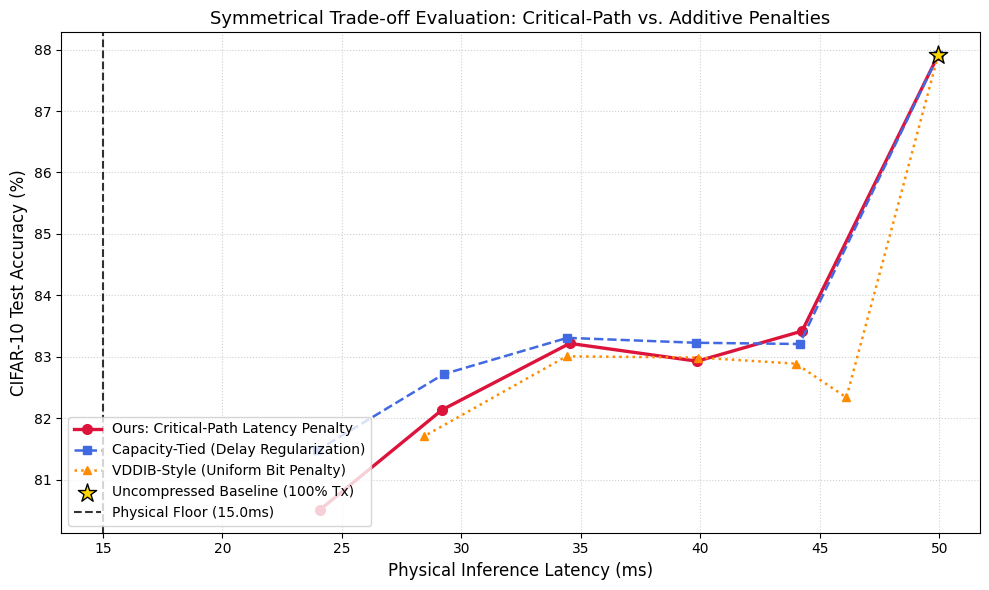

In [11]:
# Cell 7: Symmetrical Pareto Frontier Benchmark (Config 2: Capacity Asymmetry)
import copy
import matplotlib.pyplot as plt
import numpy as np
import torch

# 1. Hardware Topology (Config 2: Capacity Asymmetry)
nodes = {
    0: NodeConfig("Ingress_Pi", exec_time_ms=4.0),
    1: NodeConfig("Worker_A_Jetson", exec_time_ms=3.0),
    2: NodeConfig("Worker_B_Pi", exec_time_ms=7.0),
    3: NodeConfig("Terminal_Server", exec_time_ms=2.0),
}
edges = {
    (0, 1): ChannelConfig.from_mbps(capacity_mbps=30.0, prop_delay_ms=1.0),
    (0, 2): ChannelConfig.from_mbps(capacity_mbps=30.0, prop_delay_ms=1.0),
    (1, 3): ChannelConfig(
        capacity_bits_per_ms=50000.0, prop_delay_ms=1.0
    ),  # Fast Link (50 Mbps)
    (2, 3): ChannelConfig(
        capacity_bits_per_ms=5000.0, prop_delay_ms=1.0
    ),  # Bottleneck (5 Mbps)
}

timing_engine = DAGTimingEngine(nodes, edges)
eval_cfg = ExperimentConfig(nodes=nodes, edges=edges, lr_s=0.05)
t_irreducible = timing_engine.compute_irreducible_latency()


def load_backbone_weights(model, weights_dict):
    filtered = {
        k: v
        for k, v in weights_dict.items()
        if not (k.endswith(".s") or k.endswith(".c"))
    }
    model.load_state_dict(filtered, strict=False)


def get_clean_model():
    m = CollaborativeResNetDAG(eval_cfg).to(device)
    load_backbone_weights(m, pretrained_weights)
    for name, p in m.named_parameters():
        if name.endswith(".s") or name.endswith(".c"):
            p.requires_grad = True
            if name.endswith(".s"):
                p.data.fill_(1.0)
            if name.endswith(".c"):
                p.data.zero_()
        else:
            p.requires_grad = False
    return m


# 2. Measure Uncompressed Baseline
uncomp_model = CollaborativeResNetDAG(eval_cfg).to(device)
load_backbone_weights(uncomp_model, pretrained_weights)
for bneck in uncomp_model.get_bottleneck_map().values():
    bneck.s.data.fill_(10.0)

base_acc, base_lat, _ = UnifiedTradeoffTrainer.evaluate(
    UnifiedTradeoffTrainer(
        uncomp_model, timing_engine, eval_cfg, 0.0, "critical_path"
    ),
    test_loader,
)

print("===================================================================")
print(
    f">>> [ANCHOR] Uncompressed Baseline: Latency = {base_lat:.2f} ms | Accuracy = {base_acc:.2f}%"
)
print(
    f">>> [ASYMPTOTE] Physical Irreducible Floor: Latency = {t_irreducible:.2f} ms"
)
print("===================================================================\n")


# ------------------------------------------------------------------------------
# 3. Fast Continuation Sweep Function (Single Hyperparameter)
# ------------------------------------------------------------------------------
def run_continuation_sweep(mode, weights, epochs_per_step=3):
    print(f"\n--- Running Sweep for [{mode}] ---")
    results = []
    curr_state = copy.deepcopy(pretrained_weights)

    for w in weights:
        m = CollaborativeResNetDAG(eval_cfg).to(device)
        load_backbone_weights(m, curr_state)

        # Enable gates and imputations
        for name, p in m.named_parameters():
            if name.endswith(".s") or name.endswith(".c"):
                p.requires_grad = True

        trainer = UnifiedTradeoffTrainer(
            m, timing_engine, eval_cfg, weight=w, mode=mode
        )
        for ep in range(epochs_per_step):
            trainer.train_epoch(train_loader, ep)

        acc, lat, ret = trainer.evaluate(test_loader)
        results.append((lat, acc, w, ret))
        print(
            f"  weight = {w:.6f} -> Real Latency: {lat:.2f} ms | Accuracy: {acc:.2f}% | Retained: {ret}"
        )

        curr_state = copy.deepcopy(m.state_dict())

    return results


# ------------------------------------------------------------------------------
# 4. Execute Sweeps Across All Three Approaches
# ------------------------------------------------------------------------------
# Approach 3 (Ours: Critical-Path Latency Penalty)
# gamma scales with physical latency (ms): range [0.005, 0.15]
gamma_weights = [0.005, 0.015, 0.035, 0.07, 0.15]
tbn_res = run_continuation_sweep("critical_path", gamma_weights)

# Approach 2 (Capacity-Tied Delay Sum Penalty)
# mu scales with total delay sum (ms): range [0.005, 0.15]
mu_weights = [0.005, 0.015, 0.035, 0.07, 0.15]
app2_res = run_continuation_sweep("capacity_delay", mu_weights)

# Approach 1 (VDDIB Uniform Bits Penalty)
# beta scales with Megabits (Mb): range [0.1, 8.0]
beta_weights = [0.2, 0.8, 2.0, 4.5, 9.0]
app1_res = run_continuation_sweep("uniform_bits", beta_weights)

# ------------------------------------------------------------------------------
# 5. Publication Plot: Three Symmetrical Pareto Frontiers
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 6))

# Plot Ours (Critical Path)
tbn_lats = [base_lat] + [r[0] for r in tbn_res]
tbn_accs = [base_acc] + [r[1] for r in tbn_res]
plt.plot(
    tbn_lats,
    tbn_accs,
    "o-",
    color="crimson",
    linewidth=2.4,
    markersize=7,
    label="Ours: Critical-Path Latency Penalty",
)

# Plot Approach 2 (Capacity Delay Sum)
app2_lats = [base_lat] + [r[0] for r in app2_res]
app2_accs = [base_acc] + [r[1] for r in app2_res]
plt.plot(
    app2_lats,
    app2_accs,
    "s--",
    color="royalblue",
    linewidth=1.8,
    markersize=6,
    label="Capacity-Tied (Delay Regularization)",
)

# Plot Approach 1 (VDDIB Uniform Bits)
app1_lats = [base_lat] + [r[0] for r in app1_res]
app1_accs = [base_acc] + [r[1] for r in app1_res]
plt.plot(
    app1_lats,
    app1_accs,
    "^:",
    color="darkorange",
    linewidth=1.8,
    markersize=6,
    label="VDDIB-Style (Uniform Bit Penalty)",
)

# Anchors
plt.scatter(
    [base_lat],
    [base_acc],
    color="gold",
    edgecolors="black",
    s=190,
    zorder=6,
    marker="*",
    label="Uncompressed Baseline (100% Tx)",
)

plt.axvline(
    x=t_irreducible,
    color="black",
    linestyle="--",
    alpha=0.8,
    label=f"Physical Floor ({t_irreducible:.1f}ms)",
)

plt.xlabel("Physical Inference Latency (ms)", fontsize=12)
plt.ylabel("CIFAR-10 Test Accuracy (%)", fontsize=12)
plt.title(
    "Symmetrical Trade-off Evaluation: Critical-Path vs. Additive Penalties",
    fontsize=13,
)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="lower left", fontsize=10)
plt.tight_layout()
plt.show()